# 03. Ablation and factorial plan on the missingness variables

**Question.** Notebook 01 built ten variables out of the pattern of absence. Do they
actually make the model cheaper?

**Inputs.** `data/processed/X_fit.csv` and `y_fit.csv`.

**Outputs.** `reports/experiments.csv`, `reports/paired_comparisons.csv`, figures 08
and 09.

**Why a repeated cross-validation.** The benchmark showed standard deviations near 1 000
units on the mean cost, while the effect looked for here is of the order of a few
hundred. Five folds cannot resolve that. The whole cross-validation is therefore
repeated over 6 different fold partitions, seeds 42 to 47, giving 30 measurements per
variant, and the comparisons are paired fold by fold: the same partition evaluates both
variants, so the partition noise cancels out of the difference.

**Model held fixed.** The random forest, for its low dispersion in the benchmark. The
point here is the variables, not the model.

**Decision rule declared before running.** A difference counts only if it exceeds twice
its own standard error. Anything else is reported as non-significant, whichever way it
points.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR, PROCESSED_DIR
from src.seeding import set_seed

set_seed()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS = Path.cwd().parent / 'reports'

2026-09-02 14:42:55.608427: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 14:42:55.654222: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
X = pd.read_csv(PROCESSED_DIR / 'X_fit.csv', index_col=0)
y = pd.read_csv(PROCESSED_DIR / 'y_fit.csv', index_col=0).squeeze()

flags = [c for c in X.columns if c.startswith('missing_sb')]
print('measurement columns :', X.shape[1] - len(flags) - 1)
print('depth variable      : depth_g1')
print('sub-block flags     :', len(flags))

measurement columns : 170
depth variable      : depth_g1
sub-block flags     : 9


## 1. The variants

V0 is the chain without any missingness variable: the 170 measurement columns, imputed
and scaled, and nothing else. V1 is V0 plus the depth variable and the nine sub-block
flags, which is the configuration used by the benchmark.

A third variant, V2, appears in `reports/experiments.csv` at 6 916 units. Its definition
was not written down at the time of the run and cannot be reconstructed from the files
in this repository. Its row is kept in the results file for the record and is excluded
from the conclusions below.

In [3]:
from src.evaluation import evaluate_repeated
from src.models import random_forest

variants = {
    'V0': X.drop(columns=['depth_g1'] + flags),
    'V1': X,
}

runs = {}
for name, frame in variants.items():
    runs[name] = evaluate_repeated(random_forest, frame, y, name=name)
    mean = runs[name]['cost'].mean()
    print(f'{name} : {mean:>10,.0f}   n = {len(runs[name])}')

V0 :      7,093   n = 30
V1 :      7,071   n = 30


## 2. Factorial plan on the two candidate signals

The depth variable is not the only usage signal available. `aa_000`, the single complete
column of the file, is a usage counter, and notebook 01 showed that the depth reads as a
usage level. The two may well be carrying the same thing.

A two-by-two plan separates them: keep or drop the depth, keep or drop `aa_000`. If the
depth only helps when `aa_000` is absent, then it is a substitute for it rather than an
addition to it. The nine sub-block flags stay in every cell.

In [4]:
cells = {
    'depth + usage': X,
    'usage only': X.drop(columns=['depth_g1']),
    'depth only': X.drop(columns=['aa_000']),
    'neither': X.drop(columns=['depth_g1', 'aa_000']),
}

for name, frame in cells.items():
    runs[name] = evaluate_repeated(random_forest, frame, y, name=name)
    print(f'{name:<15} : {runs[name]["cost"].mean():>10,.0f}')

depth + usage   :      7,071
usage only      :      7,132
depth only      :      7,051
neither         :      7,070


In [5]:
experiments = pd.DataFrame({
    name: {
        'cost': r['cost'].mean(),
        'dispersion': r['cost'].std(),
        'recall': r['recall'].mean(),
        'missed_failures': r['FN'].mean(),
        'false_alarms': r['FP'].mean(),
        'auc_pr': r['auc_pr'].mean(),
    }
    for name, r in runs.items()
}).T.sort_values('cost')
experiments.to_csv(REPORTS / 'experiments.csv')
experiments.round(4)

,cost,dispersion,recall,missed_failures,false_alarms,auc_pr
depth only,7051.0000,1259.0647,0.9531,7.5000,330.1000,0.8233
neither,7069.6667,1358.6060,0.9535,7.4333,335.3000,0.8228
V1,7071.0000,1307.2170,0.9540,7.3667,338.7667,0.8235
depth + usage,7071.0000,1307.2170,0.9540,7.3667,338.7667,0.8235
V0,7092.6667,1218.4131,0.9544,7.3000,344.2667,0.8211
usage only,7132.0000,1278.2110,0.9515,7.7667,324.8667,0.8233


## 3. Paired comparison

Each comparison subtracts the two variants fold by fold on the same partition, then
reports the mean difference and the standard error of that mean. A negative difference
means the first variant is cheaper.

In [6]:
def paired(left, right, label):
    a = runs[left].sort_values(['repeat', 'fold'])['cost'].to_numpy()
    b = runs[right].sort_values(['repeat', 'fold'])['cost'].to_numpy()
    difference = a - b
    error = difference.std(ddof=1) / np.sqrt(len(difference))
    return {
        'comparison': label,
        'difference': round(float(difference.mean())),
        'standard_error': round(float(error)),
        'significant': 'yes' if abs(difference.mean()) > 2 * error else 'no',
    }

comparisons = pd.DataFrame([
    paired('V1', 'V0', 'V1 against V0'),
    paired('depth + usage', 'usage only', 'depth contribution, with aa_000'),
    paired('depth only', 'neither', 'depth contribution, without aa_000'),
    paired('depth + usage', 'depth only', 'aa_000 contribution'),
])
comparisons.to_csv(REPORTS / 'paired_comparisons.csv', index=False)
comparisons

,comparison,difference,standard_error,significant
0,V1 against V0,-22,99,no
1,"depth contribution, with aa_000",-61,139,no
2,"depth contribution, without aa_000",-19,122,no
3,aa_000 contribution,20,132,no


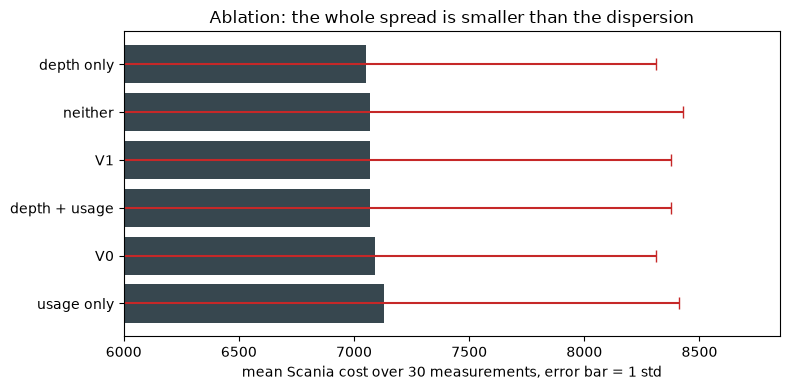

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
order = experiments.index.tolist()
ax.barh(range(len(order)), experiments.loc[order, 'cost'],
        xerr=experiments.loc[order, 'dispersion'],
        color='#37474f', ecolor='#c62828', capsize=4)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlim(left=6000)
ax.set_xlabel('mean Scania cost over 30 measurements, error bar = 1 std')
ax.set_title('Ablation: the whole spread is smaller than the dispersion')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_ablation.png', dpi=150)

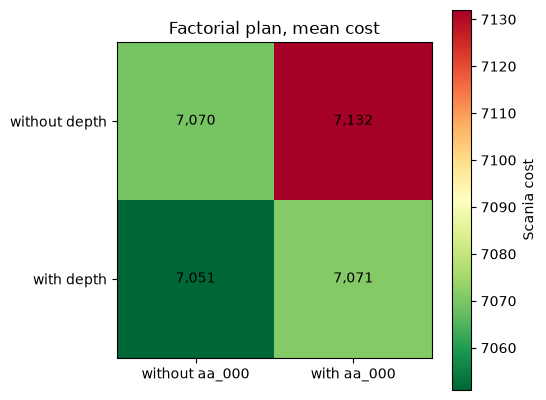

In [8]:
grid = np.array([
    [runs['neither']['cost'].mean(), runs['usage only']['cost'].mean()],
    [runs['depth only']['cost'].mean(), runs['depth + usage']['cost'].mean()],
])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
image = ax.imshow(grid, cmap='RdYlGn_r')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{grid[i, j]:,.0f}', ha='center', va='center')
ax.set_xticks([0, 1], ['without aa_000', 'with aa_000'])
ax.set_yticks([0, 1], ['without depth', 'with depth'])
ax.set_title('Factorial plan, mean cost')
fig.colorbar(image, ax=ax, label='Scania cost')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_factorial_plan.png', dpi=150)

## What comes out of this notebook

**No comparison is significant.** The differences run from 18 to 220 units for standard
errors of 157 to 337. That includes the comparison that would have validated the
feature engineering of notebook 01.

**The honest reading.** Either the effect is genuinely smaller than the noise at this
sample size, or the tree ensemble already recovers the missingness information on its
own, since a tree can split on the imputed constant and thereby rediscover the pattern.
The second explanation is plausible and untested here; testing it would mean rerunning
the plan on the logistic regression, which cannot recover it.

**What is not claimed.** The variables are kept in the chain, because they cost nothing
and because they make the model readable. They are not presented as a performance gain.

**Direction that would settle it.** 30 measurements are not enough for an effect of this
size. Resolving a 200 unit difference against a 300 unit standard error needs roughly an
order of magnitude more repeats, which is a compute budget question rather than a method
question.